In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
orders = pd.read_csv("/Users/aksharadarapaneni/data-analyst-portfolio/project-1-ecommerce/data/olist_orders_dataset.csv")
order_items = pd.read_csv("/Users/aksharadarapaneni/data-analyst-portfolio/project-1-ecommerce/data/olist_order_items_dataset.csv")
order_payments = pd.read_csv("/Users/aksharadarapaneni/data-analyst-portfolio/project-1-ecommerce/data/olist_order_payments_dataset.csv")
products = pd.read_csv("/Users/aksharadarapaneni/data-analyst-portfolio/project-1-ecommerce/data/olist_products_dataset.csv")
category_translation = pd.read_csv("/Users/aksharadarapaneni/data-analyst-portfolio/project-1-ecommerce/data/product_category_name_translation.csv")
customers = pd.read_csv("/Users/aksharadarapaneni/data-analyst-portfolio/project-1-ecommerce/data/olist_customers_dataset.csv")

In [3]:
orders.head()
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [4]:
orders['order_purchase_timestamp']=pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at']=pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date']=pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date']=pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date']=pd.to_datetime(orders['order_estimated_delivery_date'])
order_items['shipping_limit_date']=pd.to_datetime(order_items['shipping_limit_date'])

In [5]:
orders_delivered=orders[orders['order_status']=='delivered']
orders_delivered.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [6]:
orders_with_items=orders_delivered.merge(order_items,on='order_id')

In [7]:
orders_with_items.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [8]:
orders_with_items.shape

(110197, 14)

In [9]:
orders_with_items['month']= orders_with_items['order_purchase_timestamp'].dt.to_period('M')
orders_with_items['month'].head()

0    2017-10
1    2018-07
2    2018-08
3    2017-11
4    2018-02
Name: month, dtype: period[M]

In [10]:
monthly_revenue=orders_with_items.groupby('month')['price'].sum('price')
print(monthly_revenue)

month
2016-09       134.97
2016-10     40325.11
2016-12        10.90
2017-01    111798.36
2017-02    234223.40
2017-03    359198.85
2017-04    340669.68
2017-05    489338.25
2017-06    421923.37
2017-07    481604.52
2017-08    554699.70
2017-09    607399.67
2017-10    648247.65
2017-11    987765.37
2017-12    726033.19
2018-01    924645.00
2018-02    826437.13
2018-03    953356.25
2018-04    973534.09
2018-05    977544.69
2018-06    856077.86
2018-07    867953.46
2018-08    838576.64
Freq: M, Name: price, dtype: float64


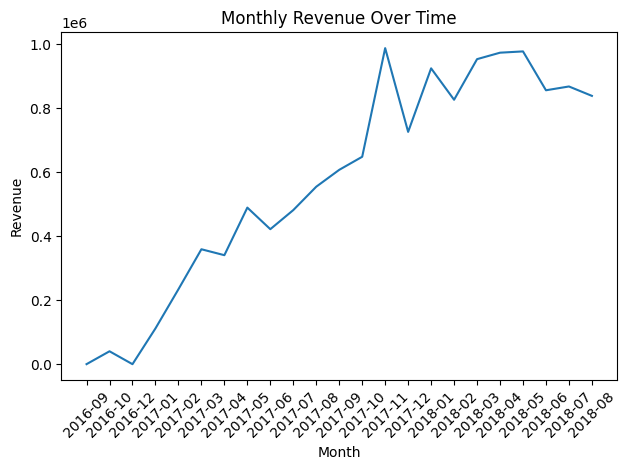

In [11]:
plt.plot(monthly_revenue.index.astype(str), monthly_revenue.values)
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.title('Monthly Revenue Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
monthly_revenue=monthly_revenue.reset_index()
monthly_revenue.head()

,month,price
0,2016-09,134.97
1,2016-10,40325.11
2,2016-12,10.90
3,2017-01,111798.36
4,2017-02,234223.40


In [13]:
monthly_revenue['mom_growth']=(monthly_revenue['price'].pct_change().round(1))*100
monthly_revenue['mom_growth'].head()

0          NaN
1      29780.0
2       -100.0
3    1025570.0
4        110.0
Name: mom_growth, dtype: float64

In [14]:
monthly_revenue[monthly_revenue['month']>='2017-01']

,month,price,mom_growth
3,2017-01,111798.36,1025570.0
4,2017-02,234223.40,110.0
5,2017-03,359198.85,50.0
6,2017-04,340669.68,-10.0
7,2017-05,489338.25,40.0
8,2017-06,421923.37,-10.0
9,2017-07,481604.52,10.0
10,2017-08,554699.70,20.0
11,2017-09,607399.67,10.0
12,2017-10,648247.65,10.0


In [15]:
order_with_products=orders_with_items.merge(products,on='product_id')

In [16]:
order_with_products.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,freight_value,month,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,8.72,2017-10,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,128e10d95713541c87cd1a2e48201934,a20e8105f23924cd00833fd87daa0831,delivered,2017-08-15 18:29:31,2017-08-15 20:05:16,2017-08-17 15:28:33,2017-08-18 14:44:43,2017-08-28,1,87285b34884572647811a353c7ac498a,...,7.78,2017-08,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
2,0e7e841ddf8f8f2de2bad69267ecfbcf,26c7ac168e1433912a51b924fbd34d34,delivered,2017-08-02 18:24:47,2017-08-02 18:43:15,2017-08-04 17:35:43,2017-08-07 18:30:01,2017-08-15,1,87285b34884572647811a353c7ac498a,...,7.78,2017-08,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
3,bfc39df4f36c3693ff3b63fcbea9e90a,53904ddbea91e1e92b2b3f1d09a7af86,delivered,2017-10-23 23:26:46,2017-10-25 02:14:11,2017-10-27 16:48:46,2017-11-07 18:04:59,2017-11-13,1,87285b34884572647811a353c7ac498a,...,14.10,2017-10,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
4,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,22.76,2018-07,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0


In [17]:
order_with_products.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'month', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm'],
      dtype='object')

In [18]:
category_revenue=order_with_products.groupby('product_category_name')['price'].sum('price').sort_values(ascending=False)
category_revenue.head(10)

product_category_name
beleza_saude              1233131.72
relogios_presentes        1166176.98
cama_mesa_banho           1023434.76
esporte_lazer              954852.55
informatica_acessorios     888724.61
moveis_decoracao           711927.69
utilidades_domesticas      615628.69
cool_stuff                 610204.10
automotivo                 578966.65
brinquedos                 471286.48
Name: price, dtype: float64

In [19]:
category_revenue=category_revenue.reset_index()

In [20]:
category_revenue=category_revenue.merge(category_translation,on='product_category_name')

In [21]:
category_revenue = category_revenue.head(10)

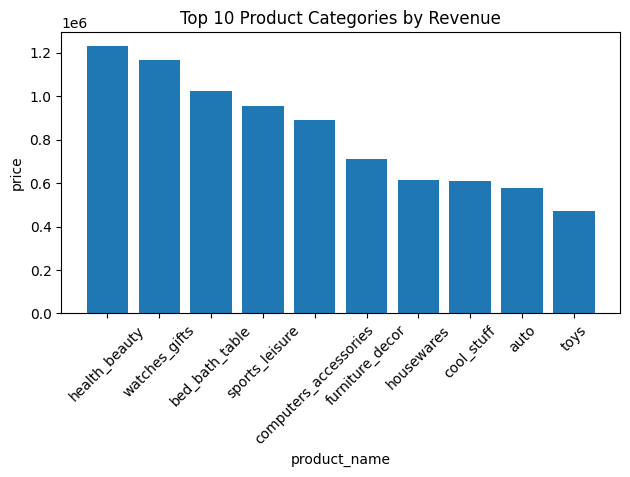

In [22]:
plt.bar(category_revenue['product_category_name_english'], category_revenue['price'])
plt.xlabel('product_name')
plt.ylabel('price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.title('Top 10 Product Categories by Revenue')
plt.show()

In [23]:
orders_delivered.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [24]:
customer_order_counts= orders_delivered.groupby('customer_id')['order_id'].count()
customer_order_counts.value_counts()

order_id
1    96478
Name: count, dtype: int64

In [25]:
orders_with_customers = customers.merge(orders_delivered, on='customer_id')

In [26]:
customer_order_counts = orders_with_customers.groupby('customer_unique_id')['order_id'].count()
customer_order_counts.value_counts()

order_id
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64

In [27]:
one_time_buyers=customer_order_counts[customer_order_counts==1]
one_time_buyers.head()

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    1
0000b849f77a49e4a4ce2b2a4ca5be3f    1
0000f46a3911fa3c0805444483337064    1
0000f6ccb0745a6a4b88665a16c9f078    1
0004aac84e0df4da2b147fca70cf8255    1
Name: order_id, dtype: int64

In [28]:
len(one_time_buyers)

90557

In [29]:
one_time_orders=orders_with_customers[orders_with_customers['customer_unique_id'].isin(one_time_buyers.index)]

In [30]:
one_time_orders.shape

(90557, 12)

In [31]:
one_time_orders=one_time_orders.merge(order_items,on='order_id')

In [32]:
one_time_orders['price'].sum()

12493089.36

In [33]:
total_revenue = order_items['price'].sum()
leakage_pct = (one_time_orders['price'].sum() / total_revenue) * 100
print(f"Total revenue: R${total_revenue:,.2f}")
print(f"One-time buyer revenue: R$12,493,089.36")
print(f"Revenue leakage: {leakage_pct:.1f}%")

Total revenue: R$13,591,643.70
One-time buyer revenue: R$12,493,089.36
Revenue leakage: 91.9%


In [36]:
import google.generativeai as genai
from dotenv import load_dotenv
import os

load_dotenv('/Users/aksharadarapaneni/data-analyst-portfolio/project-1-ecommerce/.env')
api_key = os.getenv('GEMINI_API_KEY')

genai.configure(api_key=api_key)
model = genai.GenerativeModel('gemini-2.0-flash')

print("Gemini connected!")

Gemini connected!


In [37]:
prompt = f"""
You are a senior business analyst. Based on the following e-commerce analysis findings, 
write a concise 3-paragraph executive summary suitable for a C-suite audience.

Key findings:
- Dataset: 99,441 orders from Olist Brazilian E-Commerce platform
- Total revenue: R${total_revenue:,.2f}
- Top category: Health & Beauty at R$1,233,131.72
- 94% of customers made only one purchase and never returned
- Revenue leakage: R${one_time_orders['price'].sum():,.2f} ({leakage_pct:.1f}% of total revenue) from one-time buyers
- Only 2,573 customers made 2 purchases, 181 made 3 purchases
- Monthly revenue grew from R$111,798 in Jan 2017 to R$987,765 in Nov 2017 (Black Friday spike)

Write the summary with: 
1) Overall business performance
2) Critical retention problem and its financial impact
3) Recommended actions for the business
"""

response = model.generate_content(prompt)
print(response.text)

ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash
Please retry in 25.727582592s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_input_token_count"
  quota_id: "GenerateContentInputTokensPerModelPerMinute-Fre